#Install Library

In [1]:
!pip install -q kagglehub

In [2]:
!pip install -q scikit-learn seaborn

#Import Library

In [3]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns",None)

#Business Understanding



```
# Business Understanding

## Latar Belakang

Industri perhotelan sering menghadapi tantangan berupa pembatalan reservasi (booking cancellation) yang dapat menyebabkan kehilangan pendapatan, rendahnya tingkat okupansi kamar, serta ketidakefisienan dalam perencanaan operasional.

Dengan memanfaatkan machine learning, hotel dapat memprediksi kemungkinan pembatalan reservasi sebelum tanggal check-in sehingga dapat mengambil langkah antisipasi, seperti strategi overbooking yang lebih terukur, pemberian promosi kepada pelanggan tertentu, maupun optimalisasi pengelolaan kamar.

## Tujuan

Membangun model machine learning untuk memprediksi apakah suatu reservasi hotel akan dibatalkan berdasarkan informasi reservasi yang tersedia pada saat pemesanan dilakukan.

## Machine Learning Task

Binary Classification

## Target

booking_status
```



#Download Dataset

In [4]:
path = kagglehub.dataset_download(
    "ahsan81/hotel-reservations-classification-dataset"
)

print(path)

100%|██████████| 480k/480k [00:00<00:00, 79.2MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/ahsan81/hotel-reservations-classification-dataset/versions/1


In [5]:
os.listdir(path)

['Hotel Reservations.csv']

#Load Dataset

In [6]:
csv_file = os.path.join(
    path,
    "Hotel Reservations.csv"
)

df = pd.read_csv(csv_file)

df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


#Cek Dataset

In [7]:
print(df.shape)

df.info()

(36275, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arr

#Statistik

In [8]:
df.describe(include="all")

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
count,36275,36275.000000,36275.000000,36275.000000,36275.000000,36275,36275.000000,36275,36275.000000,36275.000000,36275.000000,36275.000000,36275,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275
unique,36275,NaN,NaN,NaN,NaN,4,NaN,7,NaN,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,2
top,INN36275,NaN,NaN,NaN,NaN,Meal Plan 1,NaN,Room_Type 1,NaN,NaN,NaN,NaN,Online,NaN,NaN,NaN,NaN,NaN,Not_Canceled
freq,1,NaN,NaN,NaN,NaN,27835,NaN,28130,NaN,NaN,NaN,NaN,23214,NaN,NaN,NaN,NaN,NaN,24390
mean,NaN,1.844962,0.105279,0.810724,2.204300,NaN,0.030986,NaN,85.232557,2017.820427,7.423653,15.596995,NaN,0.025637,0.023349,0.153411,103.423539,0.619655,NaN
std,NaN,0.518715,0.402648,0.870644,1.410905,NaN,0.173281,NaN,85.930817,0.383836,3.069894,8.740447,NaN,0.158053,0.368331,1.754171,35.089424,0.786236,NaN
min,NaN,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,NaN,0.000000,2017.000000,1.000000,1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,2.000000,0.000000,0.000000,1.000000,NaN,0.000000,NaN,17.000000,2018.000000,5.000000,8.000000,NaN,0.000000,0.000000,0.000000,80.300000,0.000000,NaN
50%,NaN,2.000000,0.000000,1.000000,2.000000,NaN,0.000000,NaN,57.000000,2018.000000,8.000000,16.000000,NaN,0.000000,0.000000,0.000000,99.450000,0.000000,NaN
75%,NaN,2.000000,0.000000,2.000000,3.000000,NaN,0.000000,NaN,126.000000,2018.000000,10.000000,23.000000,NaN,0.000000,0.000000,0.000000,120.000000,1.000000,NaN


#Missing Value

In [9]:
df.isnull().sum()

,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


#Duplicate

In [10]:
print(df.duplicated().sum())

0


#DATA UNDERSTANDING & EDA



```

# Data Understanding

Dataset yang digunakan adalah **Hotel Reservation Classification Dataset**.

Dataset ini berisi informasi mengenai reservasi hotel, seperti jumlah tamu, jenis paket makan, tipe kamar, waktu pemesanan (lead time), harga kamar, riwayat reservasi pelanggan, serta status akhir reservasi.

Dataset terdiri dari **19 fitur**, dengan target berupa **booking_status** yang menunjukkan apakah reservasi **dibatalkan (Canceled)** atau **tidak dibatalkan (Not_Canceled)**.

Target yang akan diprediksi adalah **booking_status**, sehingga permasalahan yang diselesaikan merupakan **binary classification**.
```



In [11]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


#Distribusi Target

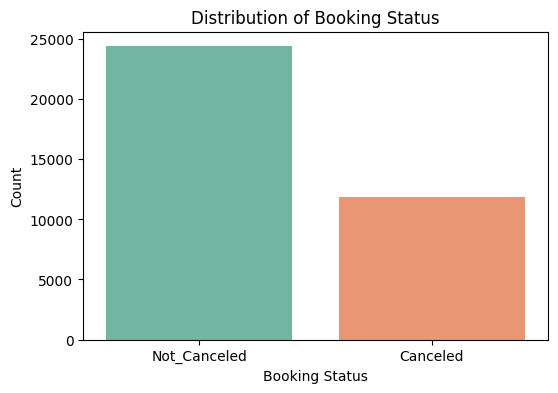

booking_status
Not_Canceled    24390
Canceled        11885
Name: count, dtype: int64
booking_status
Not_Canceled    67.24
Canceled        32.76
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="booking_status",
    data=df,
    palette="Set2"
)

plt.title("Distribution of Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Count")
plt.show()

print(df["booking_status"].value_counts())
print(round(df["booking_status"].value_counts(normalize=True)*100,2))

#Distribusi Numerik

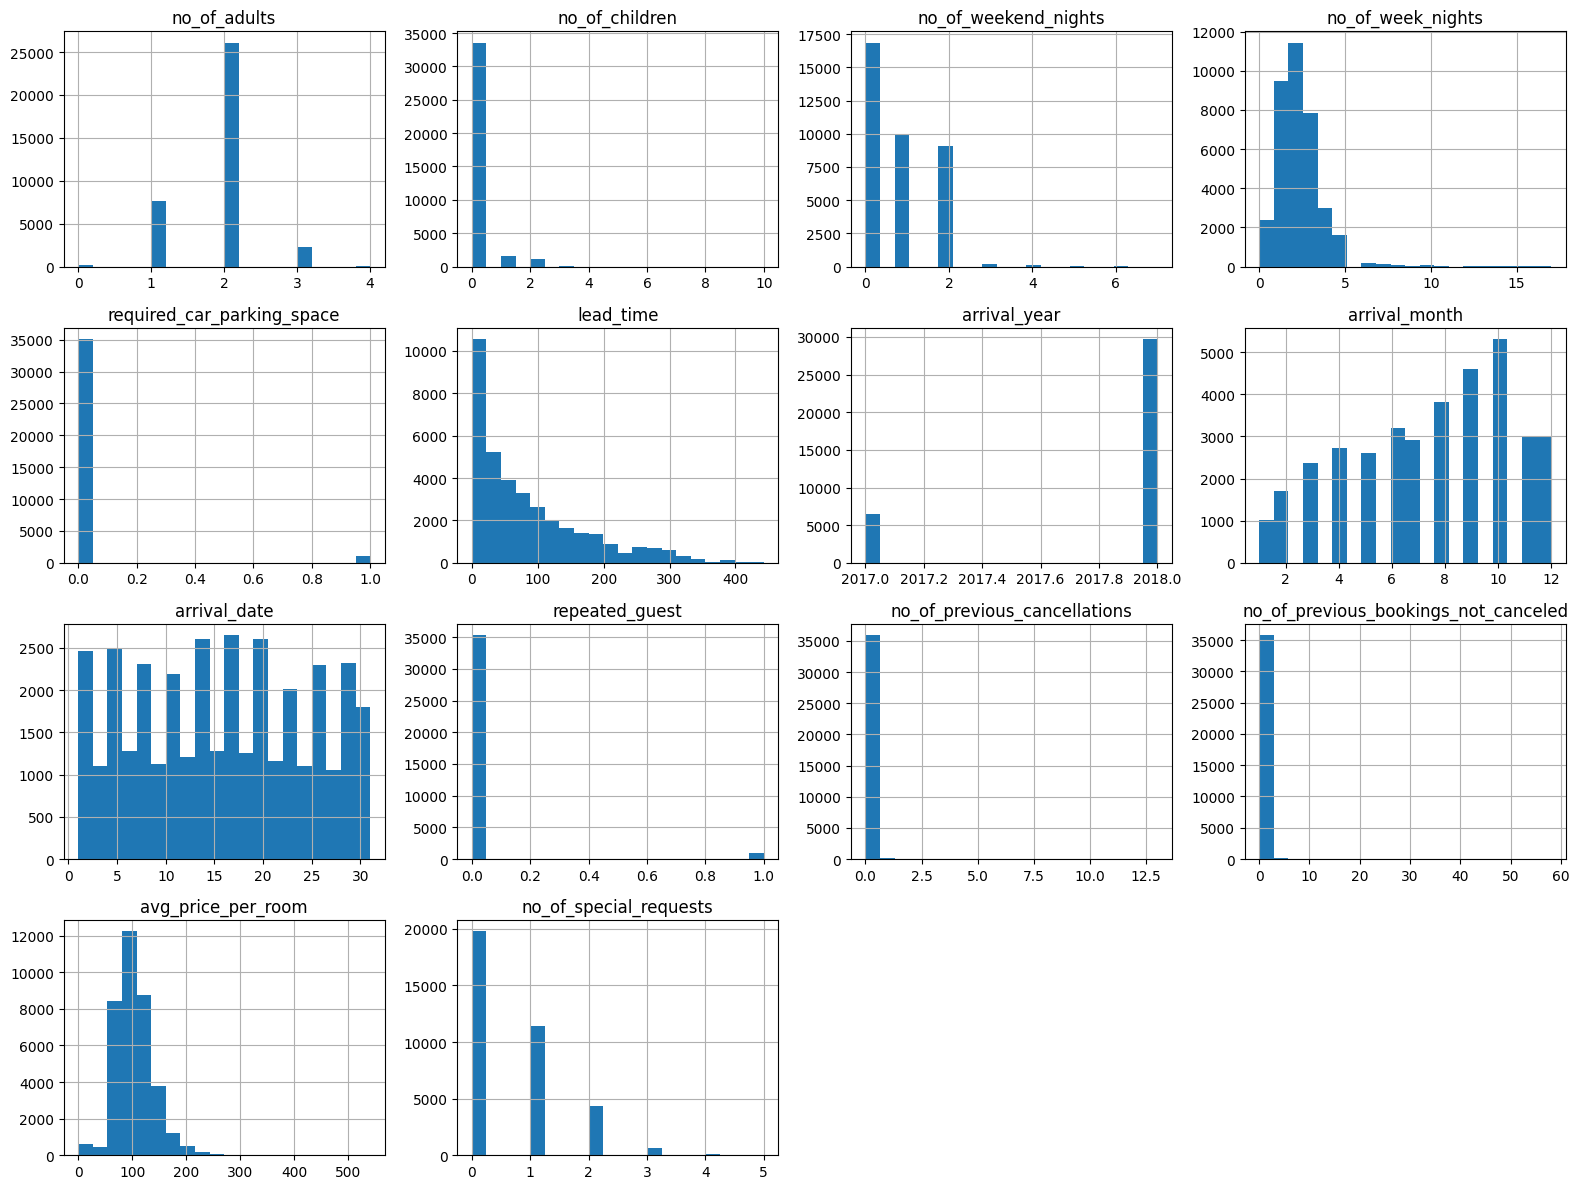

In [13]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

df[num_cols].hist(
    figsize=(16,12),
    bins=20
)

plt.tight_layout()
plt.show()

#Boxplot

In [15]:
len(num_cols)

14

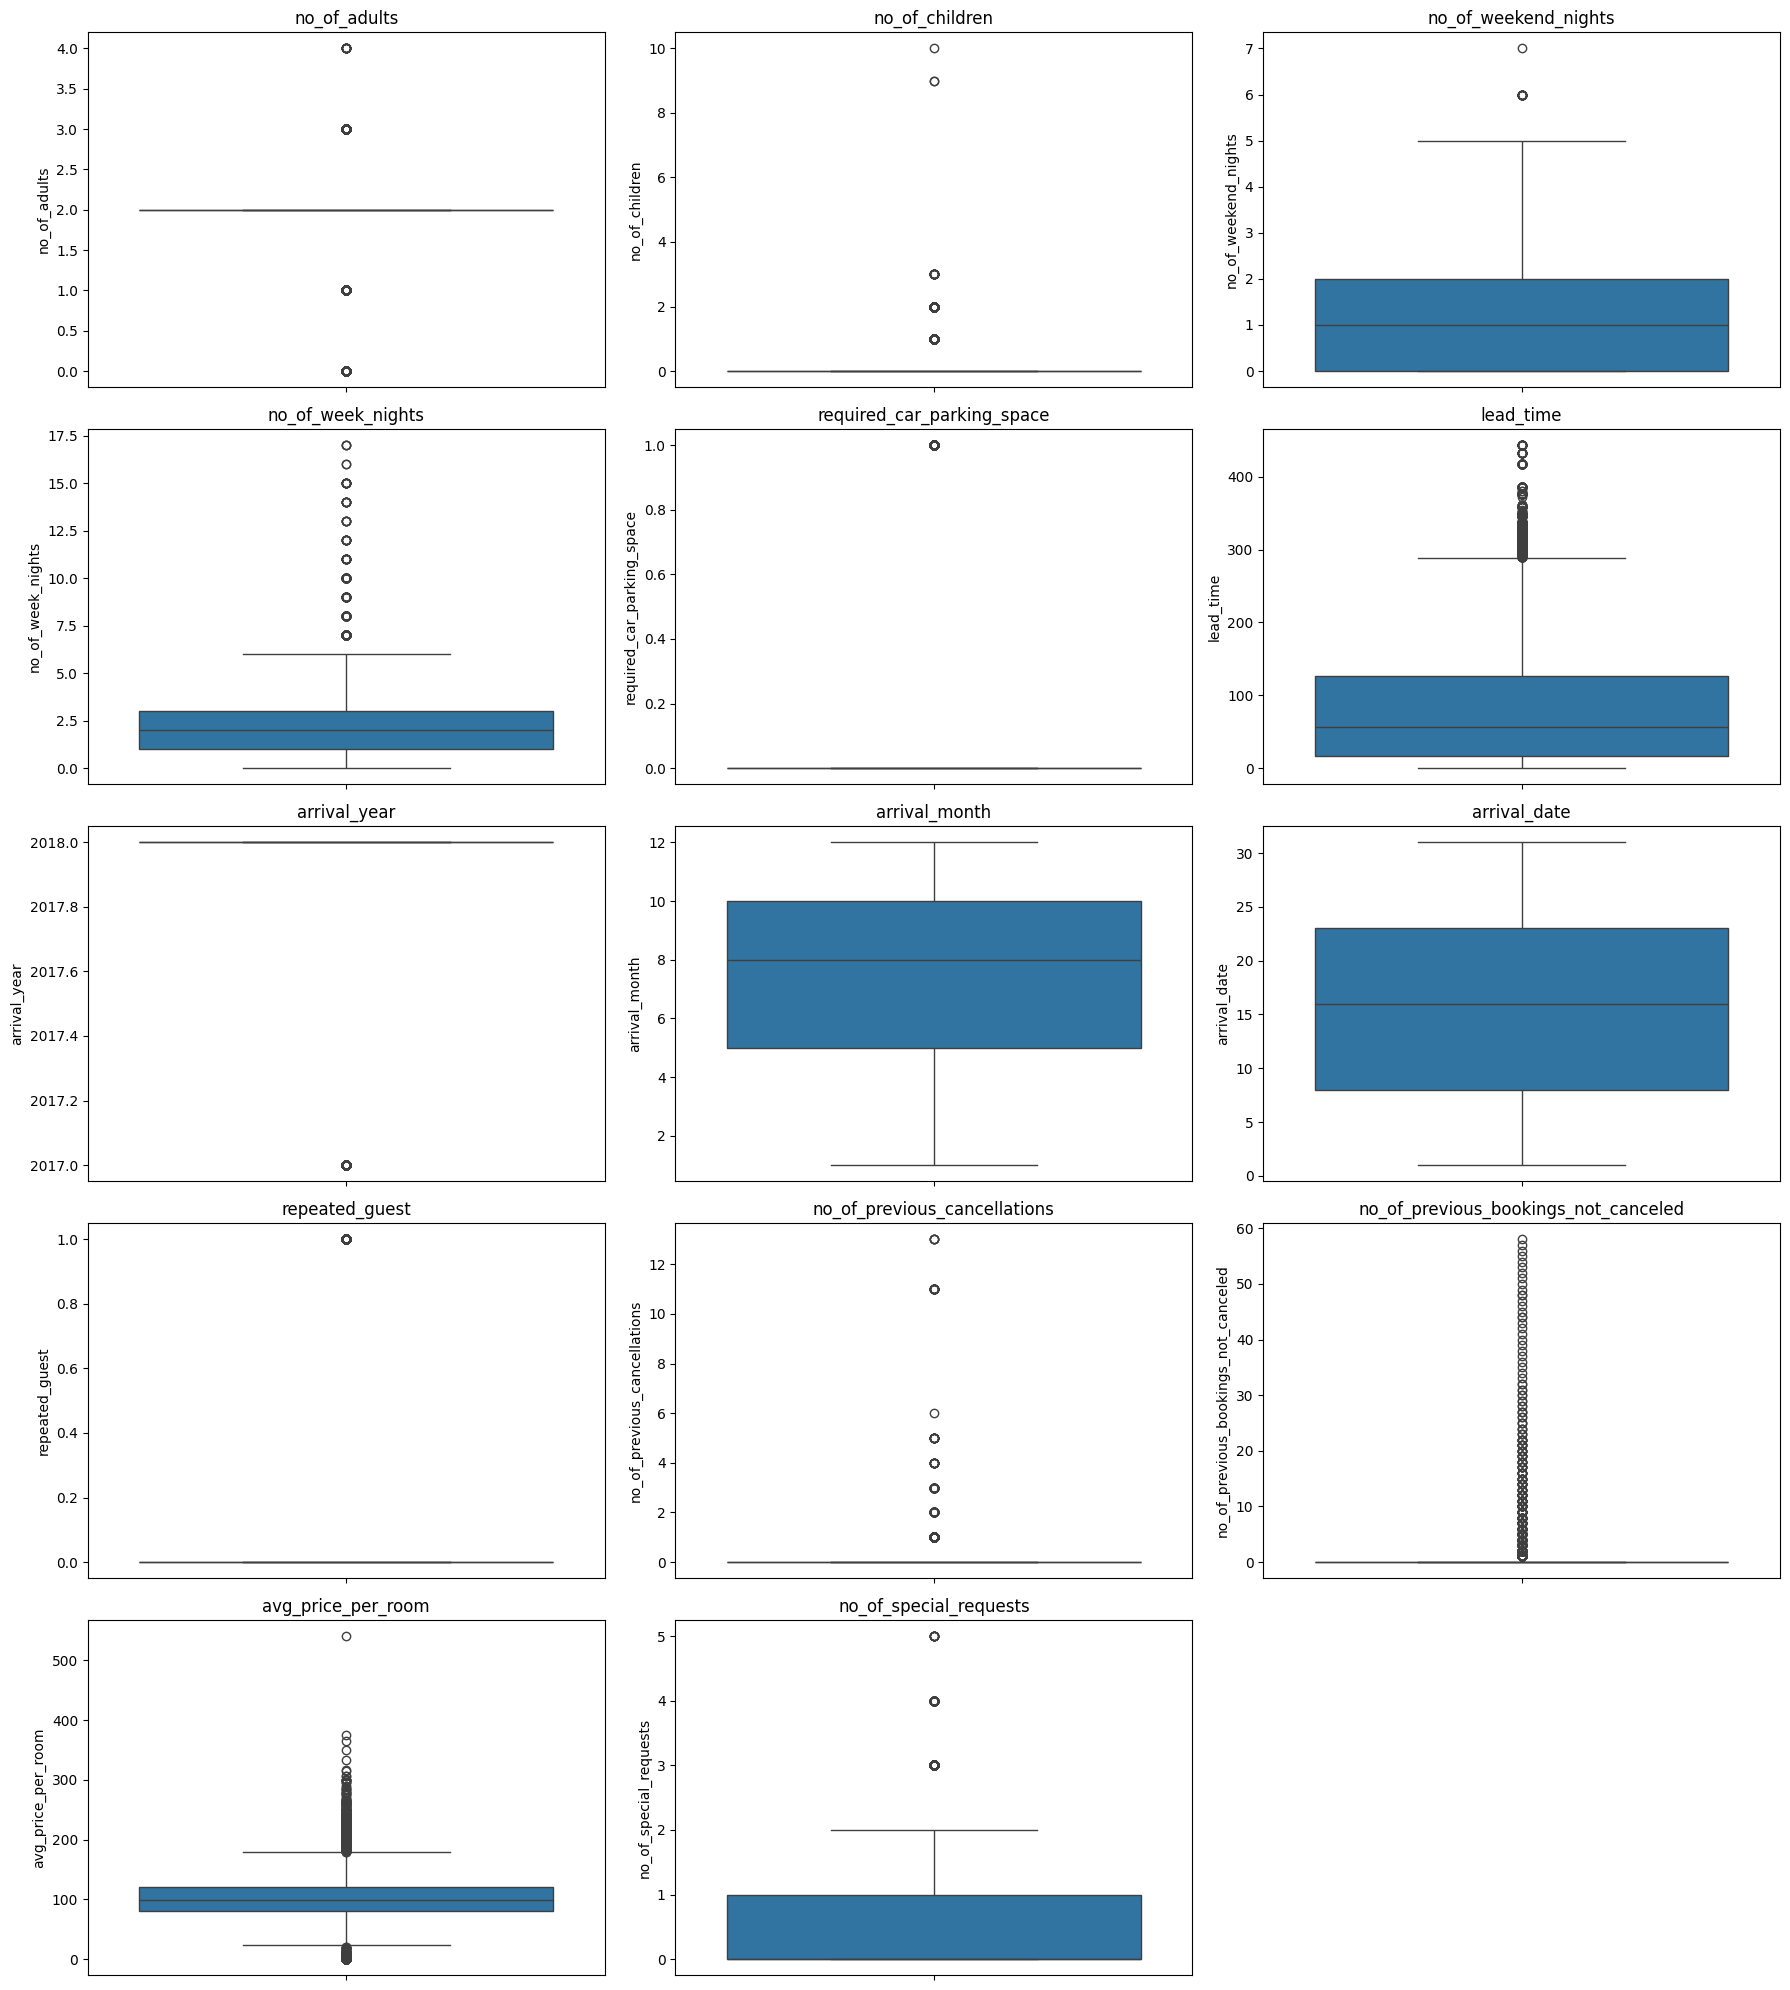

In [16]:
plt.figure(figsize=(18,20))

for i, col in enumerate(num_cols):

    plt.subplot(5,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#Korelasi

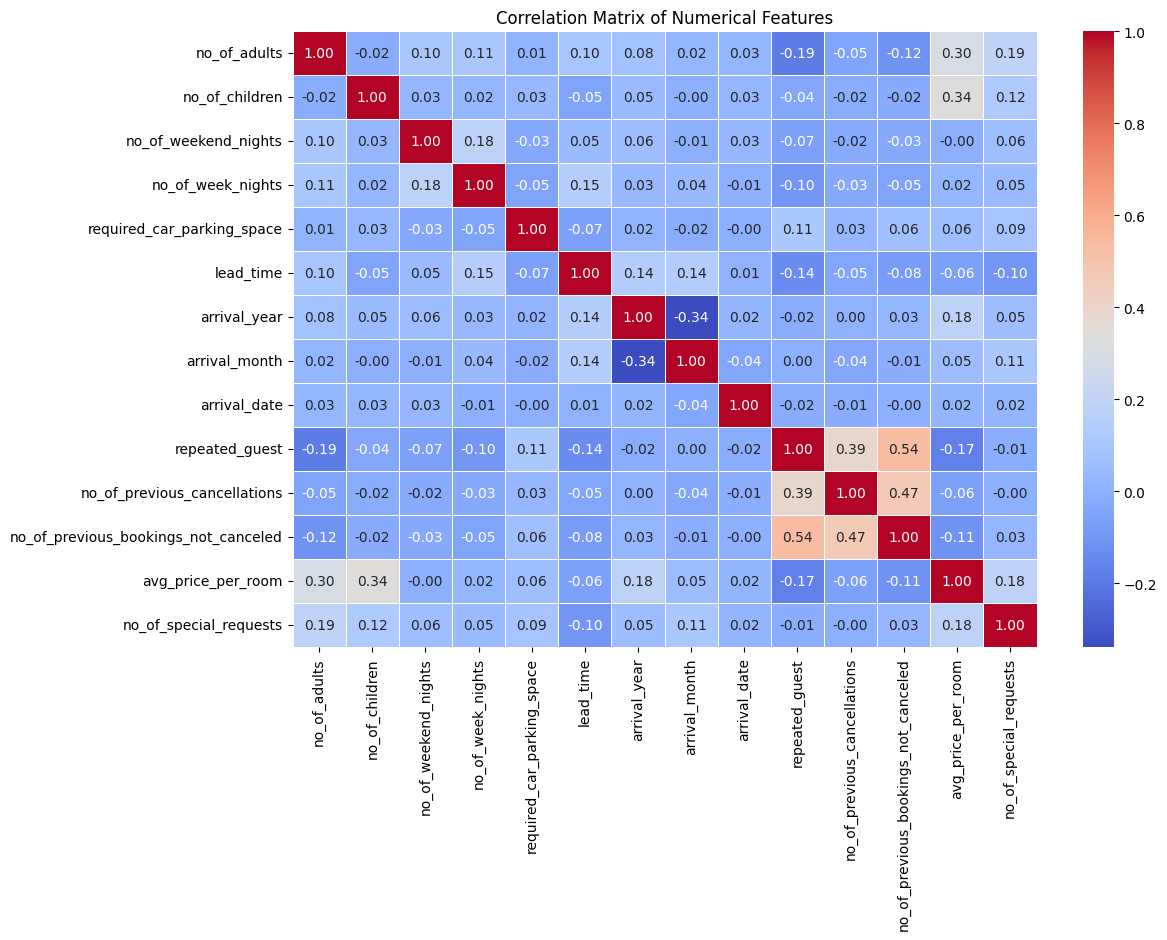

In [17]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [18]:
corr = df.select_dtypes(include=["int64","float64"]).corr()

corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .sort_values(key=abs, ascending=False)
)

corr_pairs.head(10)

repeated_guest                no_of_previous_bookings_not_canceled    0.539156
no_of_previous_cancellations  no_of_previous_bookings_not_canceled    0.468147
repeated_guest                no_of_previous_cancellations            0.390810
arrival_year                  arrival_month                          -0.339689
no_of_children                avg_price_per_room                      0.337728
no_of_adults                  avg_price_per_room                      0.296886
                              repeated_guest                         -0.192277
                              no_of_special_requests                  0.189401
avg_price_per_room            no_of_special_requests                  0.184381
no_of_weekend_nights          no_of_week_nights                       0.179577
dtype: float64

### Analisis Korelasi

Berdasarkan hasil correlation matrix, sebagian besar fitur numerik memiliki hubungan yang rendah hingga sedang. Korelasi tertinggi terdapat pada fitur `repeated_guest` dan `no_of_previous_bookings_not_canceled` dengan nilai 0,539.

Selain itu, terdapat beberapa pasangan fitur lain yang memiliki korelasi sedang, seperti `no_of_previous_cancellations` dengan `no_of_previous_bookings_not_canceled` (0,468) serta `repeated_guest` dengan `no_of_previous_cancellations` (0,391).

Namun, tidak ada pasangan fitur yang memiliki nilai korelasi di atas 0,70. Hal ini menunjukkan bahwa tidak terdapat masalah multikolinearitas yang signifikan, sehingga seluruh fitur tetap digunakan pada tahap pemodelan.

#Data Preparation

#Menghapus Kolom yang Tidak Digunakan

In [19]:
df = df.drop(columns=["Booking_ID"])

df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [20]:
X = df.drop("booking_status", axis=1)
y = df["booking_status"]

#Encoding

In [21]:
cat_cols = X.select_dtypes(include="object").columns

print(cat_cols)

Index(['type_of_meal_plan', 'room_type_reserved', 'market_segment_type'], dtype='object')


In [22]:
le = LabelEncoder()

for col in cat_cols:
    X[col] = le.fit_transform(X[col])

y = le.fit_transform(y)

In [23]:
X.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
0,2,0,1,2,0,0,0,224,2017,10,2,3,0,0,0,65.00,0
1,2,0,2,3,3,0,0,5,2018,11,6,4,0,0,0,106.68,1
2,1,0,2,1,0,0,0,1,2018,2,28,4,0,0,0,60.00,0
3,2,0,0,2,0,0,0,211,2018,5,20,4,0,0,0,100.00,0
4,2,0,1,1,3,0,0,48,2018,4,11,4,0,0,0,94.50,0


#Pisahkan Feature dan Target

In [24]:
X = df.drop("booking_status", axis=1)
y = df["booking_status"]

#Train-Test Split

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Standardisasi Fitur Numerik

In [26]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

In [ ]:
processed_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   float64
 1   SeniorCitizen     7043 non-null   float64
 2   Partner           7043 non-null   float64
 3   Dependents        7043 non-null   float64
 4   tenure            7043 non-null   float64
 5   PhoneService      7043 non-null   float64
 6   MultipleLines     7043 non-null   float64
 7   InternetService   7043 non-null   float64
 8   OnlineSecurity    7043 non-null   float64
 9   OnlineBackup      7043 non-null   float64
 10  DeviceProtection  7043 non-null   float64
 11  TechSupport       7043 non-null   float64
 12  StreamingTV       7043 non-null   float64
 13  StreamingMovies   7043 non-null   float64
 14  Contract          7043 non-null   float64
 15  PaperlessBilling  7043 non-null   float64
 16  PaymentMethod     7043 non-null   float64


In [31]:
print("Ukuran data latih :", X_train.shape)
print("Ukuran data uji   :", X_test.shape)

Ukuran data latih : (29020, 17)
Ukuran data uji   : (7255, 17)


In [32]:

df_processed = X.copy()
df_processed["booking_status"] = y


df_processed.to_csv("hotel_reservation_processed.csv", index=False)

print("Dataset berhasil disimpan!")

Dataset berhasil disimpan!


In [33]:
train_data = X_train.copy()
train_data["booking_status"] = y_train

test_data = X_test.copy()
test_data["booking_status"] = y_test

train_data.to_csv("train_processed.csv", index=False)
test_data.to_csv("test_processed.csv", index=False)

print("Train dan test berhasil disimpan!")

Train dan test berhasil disimpan!


In [34]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler berhasil disimpan!")

Scaler berhasil disimpan!


In [36]:
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

# Encoder target
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

joblib.dump(encoders, "encoders.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")

['target_encoder.pkl']